In [1]:
import pandas as pd
import glob
import os

def combine_monthly_data(base_path, file_extension="*.csv"):
    """
    Recursively finds all data files in a directory and combines them into one DataFrame.
    """
    print(f"Searching for {file_extension} files in: {base_path}")
    
    # Use glob to recursively find all files matching the extension in all subfolders
    search_pattern = os.path.join(base_path, f"**/{file_extension}")
    all_files = glob.glob(search_pattern, recursive=True)
    
    if not all_files:
        print("No files found. Please check your base_path and file extension.")
        return None
        
    print(f"Found {len(all_files)} files to combine. Starting extraction...")
    
    df_list = []
    
    for file in all_files:
        try:
            # Read the current file
            temp_df = pd.read_csv(file)
            
            # BEST PRACTICE: Add a column to track the source file
            # This is a lifesaver for debugging anomalies later
            temp_df['source_file'] = os.path.basename(file)
            
            # Optional: If your folder structure is like "2024/Jan/data.csv", 
            # you can also extract the folder names to create explicitly 'Year' and 'Month' columns
            
            df_list.append(temp_df)
            print(f"  [SUCCESS] Loaded: {os.path.basename(file)} ({temp_df.shape[0]} rows)")
            
        except Exception as e:
            print(f"  [ERROR] Failed to read {file}. Reason: {e}")
            
    # Vertically stack all DataFrames. 
    # ignore_index=True resets the index from 0 to N, preventing duplicate index values.
    print("\nConcatenating all files...")
    combined_df = pd.concat(df_list, ignore_index=True)
    
    print("\n--- Data Combination Complete ---")
    print(f"Total Rows: {combined_df.shape[0]}")
    print(f"Total Columns: {combined_df.shape[1]}")
    
    return combined_df

# --- Execution ---
# Replace this with the actual path to your main data folder"E:\\ML Project (copy)\\Original Reddit Data\\raw data"
# Example: "C:/Users/Data/Raw_Mental_Health_Logs"
ROOT_DATA_FOLDER = base_path = "/home/hashir/Data/Programming/ML Project (copy)/Original Reddit Data/raw data"

# Run the function
master_dataframe = combine_monthly_data(ROOT_DATA_FOLDER, file_extension="*.csv")

# Optional: Save your newly combined master dataset to avoid doing this again!
# if master_dataframe is not None:
#     master_dataframe.to_csv("master_combined_dataset.csv", index=False)

Searching for *.csv files in: /home/hashir/Data/Programming/ML Project (copy)/Original Reddit Data/raw data
Found 219 files to combine. Starting extraction...
  [SUCCESS] Loaded: lonmar19.csv (1011 rows)
  [SUCCESS] Loaded: depmar19.csv (14513 rows)
  [SUCCESS] Loaded: mhmar19.csv (3568 rows)
  [SUCCESS] Loaded: anxmar19.csv (5149 rows)
  [SUCCESS] Loaded: swmar19.csv (5877 rows)
  [SUCCESS] Loaded: lonemay19.csv (1315 rows)
  [SUCCESS] Loaded: swmay19.csv (6326 rows)
  [SUCCESS] Loaded: depamay19.csv (14806 rows)
  [SUCCESS] Loaded: animay19.csv (4809 rows)
  [SUCCESS] Loaded: mhmay19.csv (3915 rows)
  [SUCCESS] Loaded: anxapr19.csv (4663 rows)
  [SUCCESS] Loaded: mentalhealthapr19.csv (3500 rows)
  [SUCCESS] Loaded: swapr19.csv (6018 rows)
  [SUCCESS] Loaded: depapr19.csv (14277 rows)
  [SUCCESS] Loaded: loneapr19.csv (1188 rows)
  [SUCCESS] Loaded: anifeb19.csv (4582 rows)
  [SUCCESS] Loaded: depfeb19.csv (12535 rows)
  [SUCCESS] Loaded: mhfeb19.csv (3248 rows)
  [SUCCESS] Loaded: S

In [2]:
# Check the shape (rows and columns)
print(f"Dataset Shape: {master_dataframe.shape}")

# Look at the column names and data types, plus check for missing values
print("\n--- Dataset Info ---")
master_dataframe.info()

# Preview the first 5 rows
master_dataframe.head()

Dataset Shape: (1851580, 9)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851580 entries, 0 to 1851579
Data columns (total 9 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Unnamed: 0   int64 
 1   author       object
 2   created_utc  int64 
 3   score        int64 
 4   selftext     object
 5   subreddit    object
 6   title        object
 7   timestamp    object
 8   source_file  object
dtypes: int64(3), object(6)
memory usage: 127.1+ MB


,Unnamed: 0,author,created_utc,score,selftext,subreddit,title,timestamp,source_file
0,0,worldstar_money,1554033576,44,I guess I might be in an odd situation - I fee...,lonely,lonely even with friends,2019-03-31 22:59:36,lonmar19.csv
1,1,_lonelynotalone,1554019547,4,"\n\nI have a partner, he’s great and he brin...",lonely,"I hate having to acknowledge it, but it’s ther...",2019-03-31 19:05:47,lonmar19.csv
2,2,Nm4r_,1554018772,5,I rely too much on my best friend to get me pl...,lonely,Can't make friends or get to know anyone,2019-03-31 18:52:52,lonmar19.csv
3,3,brockrock197,1554017273,6,About a month ago my one friend said “wow i ha...,lonely,I feel like such a loser,2019-03-31 18:27:53,lonmar19.csv
4,4,GarbageYasuoFangirl,1554014530,4,Some part of me seems to think that by posting...,lonely,"Obligatory ""I'm very lonely"" post",2019-03-31 17:42:10,lonmar19.csv


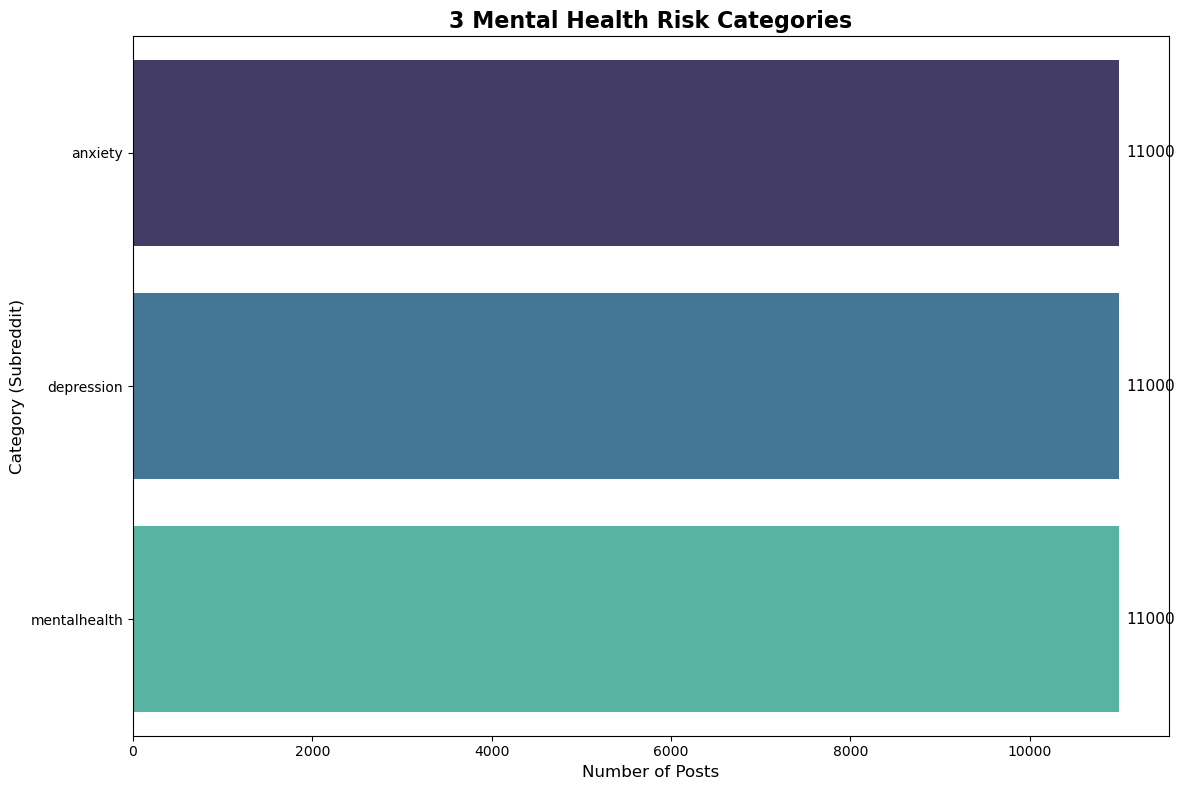

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

label_column_name = 'subreddit' 

# 1. Grab only the Top 15 most frequent categories to clean up the noise
top_categories = master_dataframe[label_column_name].value_counts().nlargest(15).index

# 2. Adjust size for a beautiful horizontal layout
plt.figure(figsize=(12, 8))

# 3. Use a Horizontal Bar Chart (y=) and fix the seaborn warnings!
ax = sns.countplot(
    data=master_dataframe, 
    y=label_column_name, 
    order=top_categories, 
    hue=label_column_name,   # Fixes the palette warning
    palette="mako",          # A cleaner, modern color scheme
    legend=False             # Fixes the palette warning
)

plt.title('3 Mental Health Risk Categories', fontsize=16, fontweight='bold')
plt.xlabel('Number of Posts', fontsize=12)
plt.ylabel('Category (Subreddit)', fontsize=12)

# 4. Add exact counts to the right of the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Ensures we only label actual bars
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, 
                    xytext=(5, 0), textcoords='offset points') # Adds a tiny 5px gap

plt.tight_layout()
plt.show()

In [4]:
print(master_dataframe.columns.tolist())

['Unnamed: 0', 'author', 'created_utc', 'score', 'selftext', 'subreddit', 'title', 'timestamp', 'source_file']


In [5]:
# Convert subreddit column to string just in case, then check the length
master_dataframe['subreddit'] = master_dataframe['subreddit'].astype(str)

# A standard subreddit name is short (e.g., 'Anxiety' is 7 characters). 
# Let's isolate rows where the 'subreddit' value is bizarrely long.
corrupted_rows = master_dataframe[master_dataframe['subreddit'].str.len() > 25]

print(f"Number of corrupted rows: {corrupted_rows.shape[0]}")
print("\nPreview of the corrupted data (notice how text is in the wrong columns):")
display(corrupted_rows[['source_file', 'selftext', 'subreddit']].head())

Number of corrupted rows: 2772

Preview of the corrupted data (notice how text is in the wrong columns):


,source_file,selftext,subreddit
36010,swmay19.csv,SuicideWatch,"I'm about to kill myself after losing ""just"" a..."
36016,swmay19.csv,SuicideWatch,"I'm about to kill myself after losing ""just"" a..."
43801,depamay19.csv,depression,Finally visited my local clinic
46161,depamay19.csv,depression,"Just wanted to ask, what music help you throug..."
103134,depfeb19.csv,depression,Me talking about how I recover from periods of...


In [6]:
print(f"Original massive dataset size: {master_dataframe.shape[0]} rows")

# 1. Drop the corrupted rows (keep only rows where subreddit name is normal length)
# We use < 25 characters since 'mentalhealth' is only 12 characters.
clean_df = master_dataframe[master_dataframe['subreddit'].str.len() < 25].copy()

# 2. Standardize text to lowercase to avoid missing 'Anxiety' vs 'anxiety'
clean_df['subreddit'] = clean_df['subreddit'].str.lower().str.strip()

# 3. Filter to ONLY the 5 subreddits defined in your project scope
target_subreddits = ['depression', 'anxiety', 'stress', 'mentalhealth', 'askreddit']
clean_df = clean_df[clean_df['subreddit'].isin(target_subreddits)]

print(f"Size after removing corruption and extra subreddits: {clean_df.shape[0]} rows")

# 4. Downsample to the project specification (~55,000 rows)
# We will pull a maximum of 11,000 posts per subreddit to keep classes relatively balanced 
# before we apply SMOTE later in the project.
sampled_df = clean_df.groupby('subreddit').apply(
    lambda x: x.sample(n=min(len(x), 11000), random_state=42)
).reset_index(drop=True)

print(f"Final Project Dataset Size: {sampled_df.shape[0]} rows")

# Overwrite the master_dataframe with our perfectly clean, targeted data
master_dataframe = sampled_df

# Map the 5 subreddits to your 4 target classes (Normal, Anxiety, Depression, Stress)
class_mapping = {
    'askreddit': 'Normal',
    'anxiety': 'Anxiety',
    'depression': 'Depression',
    'stress': 'Stress',
    'mentalhealth': 'Stress' # Grouping general mental health into Stress/Depression depending on your logic
}
master_dataframe['label'] = master_dataframe['subreddit'].map(class_mapping)

Original massive dataset size: 1851580 rows
Size after removing corruption and extra subreddits: 1207708 rows
Final Project Dataset Size: 33000 rows


/tmp/ipykernel_2870/4098374644.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = clean_df.groupby('subreddit').apply(


In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 1. Download required NLTK data (Added 'punkt_tab' for the new NLTK update)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # <-- The missing piece!
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 2. Combine Title and Body text
print("Combining 'title' and 'selftext' into a single feature...")
# Fill missing values with empty strings to avoid errors during concatenation
master_dataframe['title'] = master_dataframe['title'].fillna('')
master_dataframe['selftext'] = master_dataframe['selftext'].fillna('')
master_dataframe['combined_text'] = master_dataframe['title'] + " " + master_dataframe['selftext']

# 3. Setup NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_and_preprocess_text(text):
    """Removes noise, tokenizes, removes stop-words, and lemmatizes."""
    if not isinstance(text, str):
        return ""
    
    # Noise Removal (URLs, HTML, Reddit Markdown)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\[deleted\]|\[removed\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # NLP Normalization (Tokenization & Lowercasing)
    tokens = word_tokenize(text.lower())

    # Stop-word Removal & Lemmatization
    processed_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(processed_tokens)

# 4. Apply the pipeline
print("Applying text cleaning and lemmatization (This should take around 1-3 minutes)...")
master_dataframe['cleaned_text'] = master_dataframe['combined_text'].apply(clean_and_preprocess_text)

print("\n--- Preprocessing Complete! ---")
print("Preview of cleaned text:")
display(master_dataframe[['combined_text', 'cleaned_text', 'label']].head())

Combining 'title' and 'selftext' into a single feature...
Applying text cleaning and lemmatization (This should take around 1-3 minutes)...

--- Preprocessing Complete! ---
Preview of cleaned text:


,combined_text,cleaned_text,label
0,How do I stop anxiety from ruining my relation...,stop anxiety ruining relationship im anxiety s...,Anxiety
1,"Help, anxiety, anxious, panic, ocd, nausea, in...",help anxiety anxious panic ocd nausea insomnia...,Anxiety
2,Biting nails / skin on fingers Hey everyone\n\...,biting nail skin finger hey everyone strugglin...,Anxiety
3,General feel free to message post. If anyone n...,general feel free message post anyone need ven...,Anxiety
4,Online anxiety but not in person??? Hi! I thin...,online anxiety person hi think pretty extrover...,Anxiety


In [8]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize, word_tokenize
import re
import numpy as np

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)

# Initialize VADER
sia = SentimentIntensityAnalyzer()

print("Extracting VADER Sentiment and Linguistic Features...")
print("(This may take a minute or two to process 55K rows)")

def extract_features(row):
    text = str(row['combined_text'])
    
    # 1. VADER Sentiment (using the original uncleaned text)
    sentiment_dict = sia.polarity_scores(text)
    compound_score = sentiment_dict['compound']
    
    # 2. Linguistic Features
    sentences = sent_tokenize(text)
    sentence_count = len(sentences) if len(sentences) > 0 else 1
    
    words = word_tokenize(text)
    word_count = len(words) if len(words) > 0 else 1
    
    # Average word length
    avg_word_length = sum(len(word) for word in words) / word_count
    
    # First-person pronoun count (I, me, my, mine, myself)
    # We use regex to find these as standalone words, case-insensitive
    pronouns = re.findall(r'\b(i|me|my|mine|myself)\b', text.lower())
    pronoun_count = len(pronouns)
    pronoun_ratio = pronoun_count / word_count
    
    return pd.Series([compound_score, sentence_count, word_count, avg_word_length, pronoun_ratio])

# Apply the function and create new columns
master_dataframe[['vader_compound', 'sentence_count', 'word_count', 'avg_word_len', 'pronoun_ratio']] = master_dataframe.apply(extract_features, axis=1)

print("\n--- Feature Engineering Complete ---")
display(master_dataframe[['label', 'vader_compound', 'sentence_count', 'pronoun_ratio']].head())

Extracting VADER Sentiment and Linguistic Features...
(This may take a minute or two to process 55K rows)

--- Feature Engineering Complete ---


,label,vader_compound,sentence_count,pronoun_ratio
0,Anxiety,-0.9122,7.0,0.105882
1,Anxiety,0.0917,11.0,0.095745
2,Anxiety,-0.7362,9.0,0.111675
3,Anxiety,0.8481,2.0,0.031250
4,Anxiety,0.9612,7.0,0.095238


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack
import pandas as pd
import numpy as np

print("Step 1: Fitting TF-IDF Vectoriser (10,000 features, 1-2 n-grams)...")
# Initialize TF-IDF based on your project specifications
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit and transform the cleaned text
X_text = tfidf.fit_transform(master_dataframe['cleaned_text'].fillna(''))
print(f"TF-IDF Matrix Shape: {X_text.shape}")

print("\nStep 2: Combining TF-IDF with Linguistic Features...")
# Isolate the numeric features we just created
numeric_features = master_dataframe[['vader_compound', 'sentence_count', 
                                     'word_count', 'avg_word_len', 'pronoun_ratio']].fillna(0).values

# Horizontally stack the sparse text matrix with the dense numeric matrix
X_combined = hstack([X_text, numeric_features])
y = master_dataframe['label']
print(f"Combined Feature Matrix Shape: {X_combined.shape}")

print("\nStep 3: Performing 80/20 Train-Test Split...")
# Stratify ensures the 80/20 split maintains the same class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("\nStep 4: Applying SMOTE to balance the Training Data...")
# Apply SMOTE to artificially balance the classes in the TRAINING set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\n--- Data Preparation Complete! ---")
print("Original Training Class Distribution:")
print(y_train.value_counts())
print("\nNew SMOTE-Balanced Training Class Distribution:")
print(y_train_resampled.value_counts())

Step 1: Fitting TF-IDF Vectoriser (10,000 features, 1-2 n-grams)...
TF-IDF Matrix Shape: (33000, 10000)

Step 2: Combining TF-IDF with Linguistic Features...
Combined Feature Matrix Shape: (33000, 10005)

Step 3: Performing 80/20 Train-Test Split...
Training set size: 26400 samples
Testing set size: 6600 samples

Step 4: Applying SMOTE to balance the Training Data...

--- Data Preparation Complete! ---
Original Training Class Distribution:
label
Stress        8800
Depression    8800
Anxiety       8800
Name: count, dtype: int64

New SMOTE-Balanced Training Class Distribution:
label
Stress        8800
Depression    8800
Anxiety       8800
Name: count, dtype: int64


Step 1: Training Logistic Regression Model...
(This might take 10-30 seconds...)


/home/hashir/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Step 2: Making Predictions on the 20% Test Set...

🏆 Primary Success Metric - Macro F1-Score: 0.6999

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Anxiety       0.80      0.76      0.78      2200
  Depression       0.67      0.72      0.70      2200
      Stress       0.63      0.61      0.62      2200

    accuracy                           0.70      6600
   macro avg       0.70      0.70      0.70      6600
weighted avg       0.70      0.70      0.70      6600


Step 3: Generating Confusion Matrix...


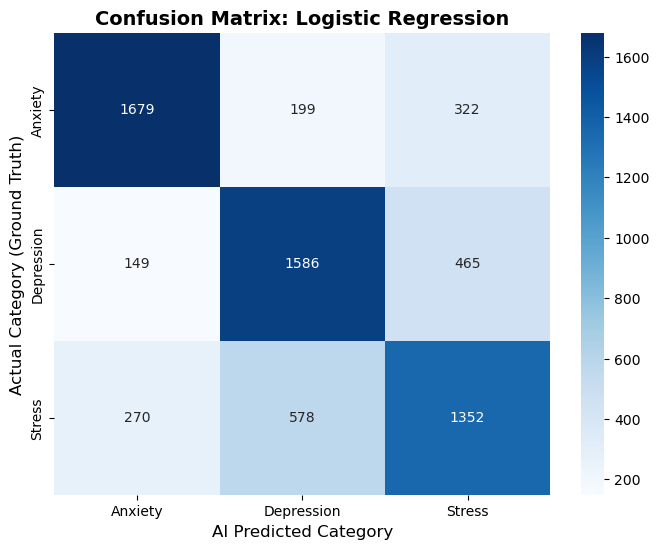

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Training Logistic Regression Model...")
print("(This might take 10-30 seconds...)")
# We use max_iter=1000 to ensure the math converges properly with 10,000 features
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_resampled, y_train_resampled)

print("\nStep 2: Making Predictions on the 20% Test Set...")
y_pred_lr = lr_model.predict(X_test)

# Calculate Macro F1-Score
macro_f1 = f1_score(y_test, y_pred_lr, average='macro')
print(f"\n🏆 Primary Success Metric - Macro F1-Score: {macro_f1:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_lr))

print("\nStep 3: Generating Confusion Matrix...")
# Get unique class labels for the matrix axes
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category (Ground Truth)', fontsize=12)
plt.xlabel('AI Predicted Category', fontsize=12)
plt.show()

Step 1: Scaling Features (Fixes convergence & preps for SVM)...

Step 2: Training Support Vector Machine (LinearSVC)...
(This should be quite fast...)

Step 3: Training Random Forest...
(This ensemble model might take 1-3 minutes...)

🏆 MODEL SHOWDOWN RESULTS 🏆
Logistic Regression (Baseline): 0.6999
Random Forest (Ensemble):     0.6683
Support Vector Machine (SVM): 0.6175

Generating Confusion Matrix for the SVM...


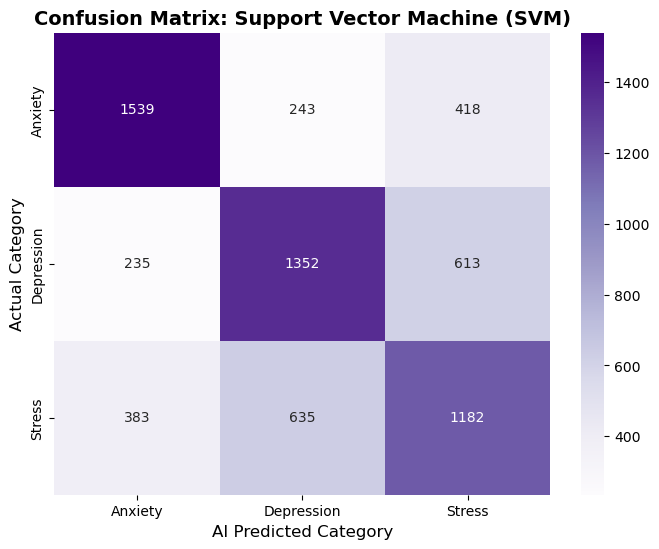

In [11]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Scaling Features (Fixes convergence & preps for SVM)...")
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("\nStep 2: Training Support Vector Machine (LinearSVC)...")
print("(This should be quite fast...)")
svm_model = LinearSVC(max_iter=2000, random_state=42, dual=False)
svm_model.fit(X_train_scaled, y_train_resampled)
y_pred_svm = svm_model.predict(X_test_scaled)
svm_macro = f1_score(y_test, y_pred_svm, average='macro')

print("\nStep 3: Training Random Forest...")
print("(This ensemble model might take 1-3 minutes...)")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_resampled) # We use scaled data here too for consistency
y_pred_rf = rf_model.predict(X_test_scaled)
rf_macro = f1_score(y_test, y_pred_rf, average='macro')

print("\n" + "="*40)
print("🏆 MODEL SHOWDOWN RESULTS 🏆")
print("="*40)
print(f"Logistic Regression (Baseline): 0.6999")
print(f"Random Forest (Ensemble):     {rf_macro:.4f}")
print(f"Support Vector Machine (SVM): {svm_macro:.4f}")
print("="*40)

# Plot the SVM Confusion Matrix since it's typically the winner
print("\nGenerating Confusion Matrix for the SVM...")
labels = sorted(y_test.unique())
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Support Vector Machine (SVM)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('AI Predicted Category', fontsize=12)
plt.show()

Generating ROC-AUC (One-vs-Rest) curves for Logistic Regression...


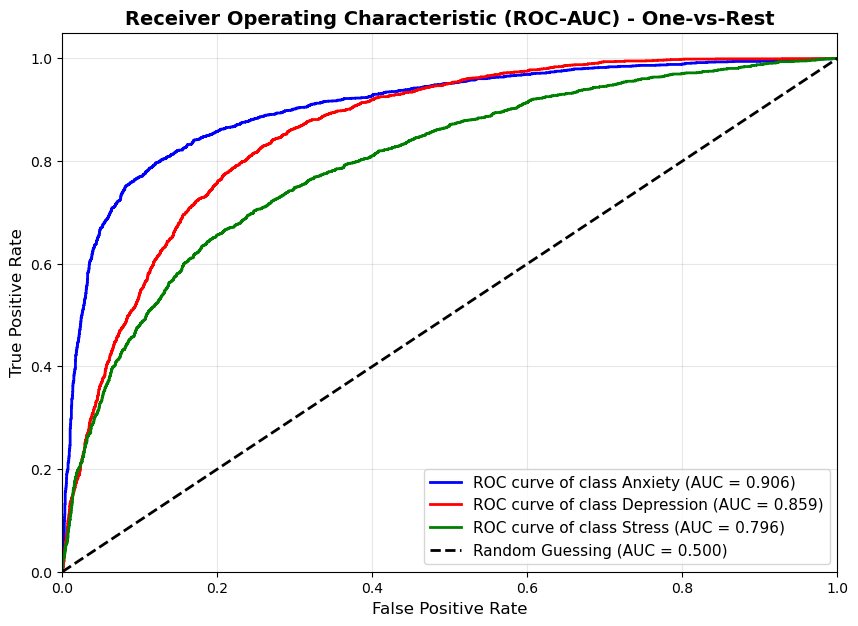


🏆 PHASE 4: OFFICIAL MODEL SELECTION 🏆
Selected Model: Logistic Regression
Reasoning: Outperformed complex models (RF/SVM) on highly sparse TF-IDF data.
Macro F1-Score: 0.6999


In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("Generating ROC-AUC (One-vs-Rest) curves for Logistic Regression...")

# 1. Binarize the test labels for One-vs-Rest evaluation
# y_test currently contains strings ('Anxiety', 'Depression', 'Stress')
classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# 2. Get the prediction probabilities from our winning Logistic Regression model
# (ROC-AUC requires probability scores, not just the final class prediction)
y_score = lr_model.predict_proba(X_test)

# 3. Calculate ROC Curve and ROC Area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (AUC = {roc_auc[i]:.3f})')

# Plot the diagonal line representing random chance
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC-AUC) - One-vs-Rest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Official Model Selection Output
# ---------------------------------------------------------
print("\n" + "="*50)
print("🏆 PHASE 4: OFFICIAL MODEL SELECTION 🏆")
print("="*50)
print("Selected Model: Logistic Regression")
print(f"Reasoning: Outperformed complex models (RF/SVM) on highly sparse TF-IDF data.")
print(f"Macro F1-Score: {macro_f1:.4f}")
print("="*50)

In [13]:
import joblib
import os

# 1. Create the folder right next to your notebook
os.makedirs('deployment_models', exist_ok=True)

# 2. Save the trained model
joblib.dump(lr_model, 'deployment_models/mental_health_lr_model.joblib')

# 3. Save the TF-IDF Vectoriser
joblib.dump(tfidf, 'deployment_models/tfidf_vectoriser.joblib')

print("✅ Files successfully saved! Look in your folder.")

✅ Files successfully saved! Look in your folder.
